> **Running this notebook:** This notebook requires `matplotlib` for plotting and `netcdf4` to read the example dataset, in addition to xgcm's core dependencies. If you have cloned the repo, the pixi `docs` environment includes everything needed — launch Jupyter with `pixi run notebooks`. Otherwise install `xgcm`, `matplotlib`, and `netcdf4` into your environment.

# Grid Metrics
Most modern circulation models discretize the partial differential equations needed to simulate the earth system on a logically rectangular grid. This means the grid for a single time step can be represented as a 3-dimensional array of cells. Even for more complex grid geometries like [here](https://xgcm.readthedocs.io/en/latest/grid_topology/), subdomains are usually organized in this manner. A noteable exception are models with unstructured grids [example](https://en.wikipedia.org/wiki/Unstructured_grid), which currently cannot be processed with the datamodel of xarray and xgcm.

Our grid operators work on the logically rectangular grid of an ocean model, meaning that e.g. differences are evaluated on the 'neighboring' cells in either direction, but even though these cells are adjacent, cells can have different size and geometry.

In order to convert operators acting on the logically rectangular grid to physically meaningful output models need 'metrics' - information about the grid cell geometry in physical space.
In the case of a perfectly [rectangular cuboid](https://en.wikipedia.org/wiki/Cuboid), the only metrics needed would be three of the edge distances. All other distances can be reconstructed exactly. Most ocean models have however slightly distorted cells, due to the curvature of the earth. To accurately represent the volume of the cell we require more metrics. 

Each grid point has three kinds of fundamental metrics associated with it which differ in the number of described axes:

1. **Distances**: A distance is associated with a single axis (e.g. `('X',)`,`('Y',)` or `('Z',)`). Each distance describes the distance from the point to either face of the cell associated with the grid point. 
2. **Areas**: An area is associated with a pair of axes (e.g. `('X', 'Y')`, `('Y', 'Z')` and `('X', 'Z')`). Each grid point intersects three areas.
3. **Volume**: The cell volume is unique for each cell and associated with all three axes (`('X', 'Y', 'Z')`).

## Using metrics with xgcm
Once the user assigns the metrics (given as coordinates in most model output) to the `grid` object, xgcm is able to automatically select and apply these to calculate e.g. derivatives and integrals from model data. 

<div class="alert alert-info">

*Note*: xgcm does not currently check for alignment of missing values between data and metrics. The user needs to check and mask values appropriately

</div>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from xgcm import Grid

%matplotlib inline

In [2]:
import pooch

fname = pooch.retrieve(
    url="doi:10.5281/zenodo.21251181/mitgcm_example_dataset_v2.nc",
    known_hash="md5:3176deb0b4d556d2981dff03ba2ed624",
)
ds = xr.open_dataset(fname)
ds

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 1, Z: 15, YC: 40, XG: 90, YG: 40, XC: 90, Zl: 15)
Coordinates: (12/25)
  * time     (time) int64 8B 39600
    iter     (time) int64 8B ...
  * Z        (Z) float32 60B -25.0 -85.0 -170.0 ... -4.19e+03 -4.855e+03
    PHrefC   (Z) float32 60B ...
    drF      (Z) float32 60B ...
  * YC       (YC) float32 160B -78.0 -74.0 -70.0 -66.0 ... 66.0 70.0 74.0 78.0
    ...       ...
    hFacS    (Z, YG, XC) float32 216kB ...
    Depth    (YC, XC) float32 14kB ...
    dxG      (YG, XC) float32 14kB ...
    rAs      (YG, XC) float32 14kB ...
    maskS    (Z, YG, XC) bool 54kB ...
  * Zl       (Zl) float32 60B 0.0 -50.0 -120.0 ... -3.28e+03 -3.87e+03 -4.51e+03
Data variables:
    UVEL     (time, Z, YC, XG) float32 216kB ...
    VVEL     (time, Z, YG, XC) float32 216kB ...
    WVEL     (time, Zl, YC, XC) float32 216kB ...
    SALT     (time, Z, YC, XC) float32 216kB ...
    THETA    (time, Z, YC, XC) float32 216kB ...
    PH       (time, Z, YC, XC) float32 216kB ...
    Eta      (time, YC, XC) float32 14kB ...
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(extra_metadata=None, ll...

For mitgcm output we need to first incorporate partial cell thicknesses into new metric coordinates

In [3]:
ds["drW"] = ds.hFacW * ds.drF  # vertical cell size at u point
ds["drS"] = ds.hFacS * ds.drF  # vertical cell size at v point
ds["drC"] = ds.hFacC * ds.drF  # vertical cell size at tracer point

To assign the metrics, the user has to provide a dictionary with keys and entries corresponding to the spatial orientation of the metrics and a list of the appropriate variable names in the dataset. 

In [4]:
metrics = {
    ("X",): ["dxC", "dxG"],  # X distances
    ("Y",): ["dyC", "dyG"],  # Y distances
    ("Z",): ["drW", "drS", "drC"],  # Z distances
    ("X", "Y"): ["rA", "rAz", "rAs", "rAw"],  # Areas
}
grid = Grid(ds, metrics=metrics)

## Grid-aware (weighted) integration

It is now possible to integrate over any grid axis. For example, we can integrate over the Z axis to compute the 
discretized version of:

$$ \int_{-H}^0 u dz$$

in one line:

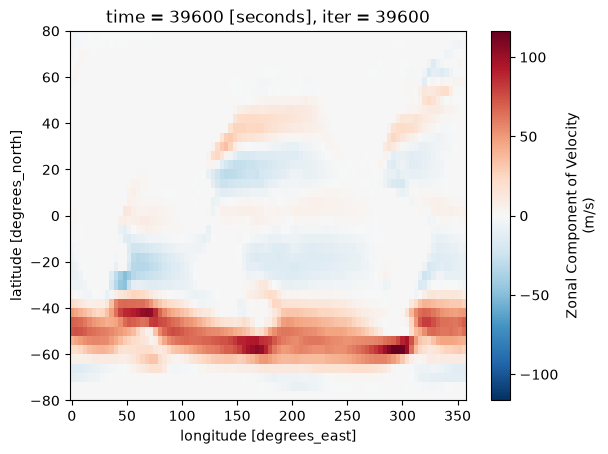

In [5]:
grid.integrate(ds.UVEL, "Z").plot();

This is equivalent to doing `(ds.UVEL * ds.drW).sum('Z')`, with the advantage of not having to remember the name of the appropriate metric and the matching dimension. The only thing the user needs to input is the axis to integrate over.

In [6]:
a = grid.integrate(ds.UVEL, "Z")
b = (ds.UVEL * ds.drW).sum("Z")
xr.testing.assert_equal(a, b)

We can do the exact same thing on a tracer field (which is located on a different grid point) by using the exact same syntax:

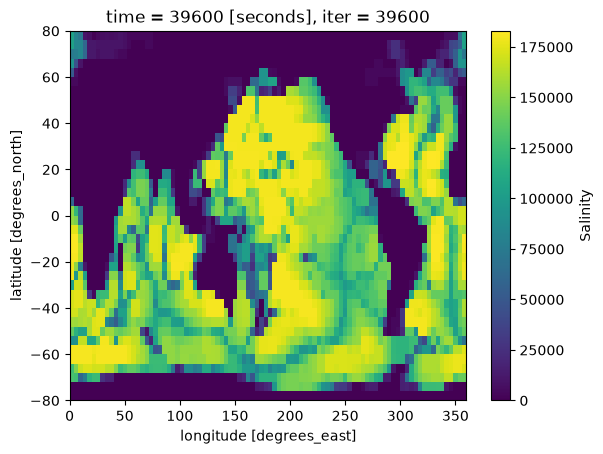

In [7]:
grid.integrate(ds.SALT, "Z").plot();

It also works in two dimensions:

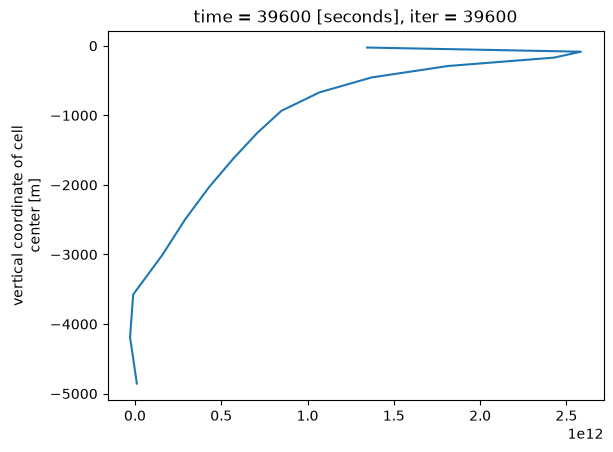

In [8]:
a = grid.integrate(ds.UVEL, ["X", "Y"])
a.plot(y="Z")

# Equivalent to integrating over area
b = (ds.UVEL * ds.rAw).sum(["XG", "YC"])
xr.testing.assert_equal(a, b)

And finally in 3 dimensions, this time using the salinity of the tracer cell:

In [9]:
print(
    "Spatial integral of zonal velocity: ",
    grid.integrate(ds.UVEL, ["X", "Y", "Z"]).values,
)

Spatial integral of zonal velocity:  [2.367449e+15]


/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-a29807edc97904fd9/xgcm/grid.py:521: UserWarning: Metric at ('time', 'Z', 'YC', 'XG') being interpolated from metrics at dimensions [('YC', 'XC'), ('Z', 'YC', 'XG')]. Boundary value set to 'extend'.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-a29807edc97904fd9/xgcm/grid.py:521: UserWarning: Metric at ('time', 'Z', 'YC', 'XG') being interpolated from metrics at dimensions [('YC', 'XC'), ('Z', 'YG', 'XC')]. Boundary value set to 'extend'.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-a29807edc97904fd9/xgcm/grid.py:521: UserWarning: Metric at ('time', 'Z', 'YC', 'XG') being interpolated from metrics at dimensions [('YC', 'XC'), ('Z', 'YC', 'XC')]. Boundary value set to 'extend'.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-a29807edc97904fd9/xgcm/grid.py:521: UserWarning: Metric at ('time', 'Z', 'YC', 'XG') being interpolated from metrics at dimensions [('YG', 'XG'

But wait, we did not provide a cell volume when setting up the `Grid`. What happened?

Whenever no matching metric is provided, xgcm will default to reconstruct it from the other available metrics, in this case the area and z distance of the tracer cell

In [10]:
a = grid.integrate(ds.SALT, ["X", "Y", "Z"])
b = (ds.SALT * ds.rA * ds.drC).sum(["XC", "YC", "Z"])
xr.testing.assert_allclose(a, b)

/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-a29807edc97904fd9/xgcm/grid.py:521: UserWarning: Metric at ('time', 'Z', 'YC', 'XC') being interpolated from metrics at dimensions [('YC', 'XC'), ('Z', 'YC', 'XG')]. Boundary value set to 'extend'.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-a29807edc97904fd9/xgcm/grid.py:521: UserWarning: Metric at ('time', 'Z', 'YC', 'XC') being interpolated from metrics at dimensions [('YC', 'XC'), ('Z', 'YG', 'XC')]. Boundary value set to 'extend'.
  warnings.warn(


## Grid-aware (weighted) average

xgcm can also calcualate the weighted average along each axis and combinations of axes. 
See for example the vertical average of salinity:

$$ \frac{\int_{-H}^0 S dz}{\int_{-H}^0 dz} $$ 

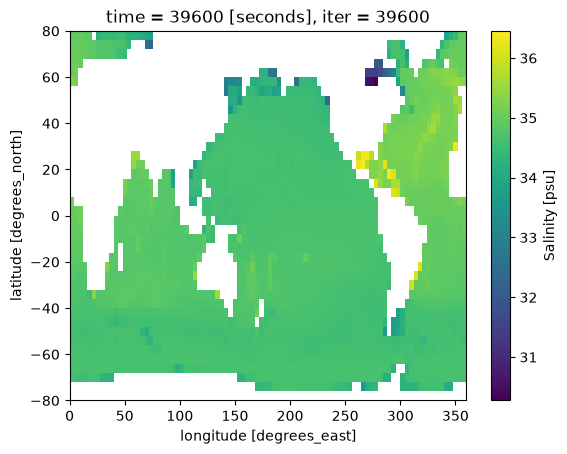

In [11]:
# depth mean salinity
grid.average(ds.SALT, ["Z"]).plot();

Equivalently, this can be computed with the xgcm operations:

```
(ds.SALT * ds.drF).sum('Z') / ds.drF.sum('Z')
```

See also for zonal velocity:

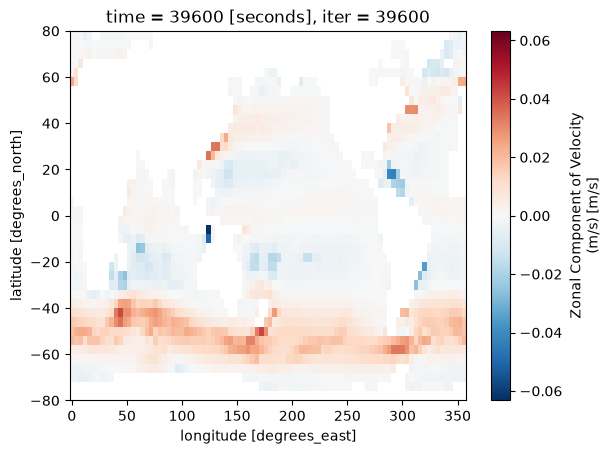

In [12]:
# depth mean zonal velocity
grid.average(ds.UVEL, ["Z"]).plot();

This works with multiple dimensions as well: 

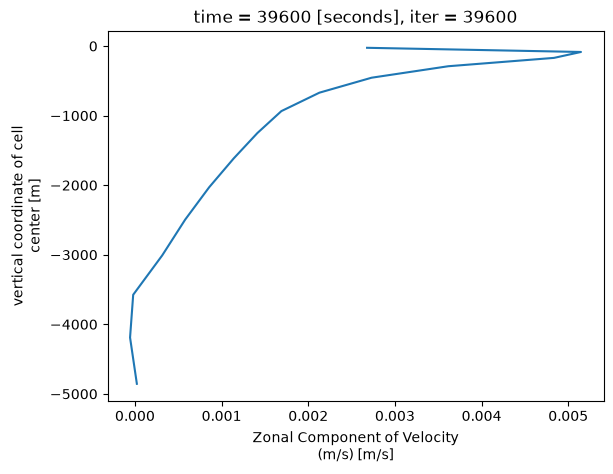

In [13]:
# horizontal average zonal velocity
grid.average(ds.UVEL, ["X", "Y"]).plot(y="Z");

In [14]:
# average salinity of the global ocean
# horizontal average zonal velocity
print(
    "Volume weighted average of salinity: ",
    grid.average(ds.SALT, ["X", "Y", "Z"]).values,
)

Volume weighted average of salinity:  [34.73096]


/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-a29807edc97904fd9/xgcm/grid.py:521: UserWarning: Metric at ('time', 'Z', 'YC', 'XC') being interpolated from metrics at dimensions [('YC', 'XC'), ('Z', 'YC', 'XG')]. Boundary value set to 'extend'.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-a29807edc97904fd9/xgcm/grid.py:521: UserWarning: Metric at ('time', 'Z', 'YC', 'XC') being interpolated from metrics at dimensions [('YC', 'XC'), ('Z', 'YG', 'XC')]. Boundary value set to 'extend'.
  warnings.warn(


## Cumulative integration

Using the metric-aware cumulative integration `cumint`, we can calculate the [barotropic transport streamfunction](https://xgcm.readthedocs.io/en/latest/xgcm-examples/02_mitgcm/#barotropic-transport-streamfunction) even easier and more intuitive in one line:

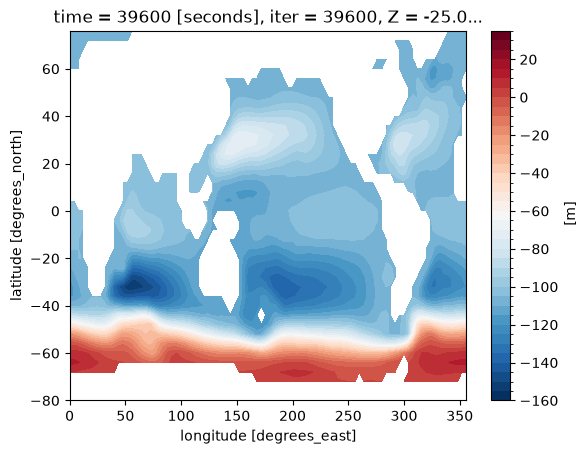

In [15]:
# the streamfunction is the cumulative integral of the vertically integrated zonal velocity along y
psi = grid.cumint(-grid.integrate(ds.UVEL, "Z"), "Y", boundary="fill")

maskZ = grid.interp(ds.hFacS, "X").isel(Z=0)
(psi / 1e6).squeeze().where(maskZ).plot.contourf(levels=np.arange(-160, 40, 5));

Here, `cumint` is performing the discretized form of:

$$ \psi = \int_{y_0}^{y} -U  dy' $$

where $U = \int_{-H}^0 u dz$, and under the hood looks like the following operation: 

```
grid.cumsum( -grid.integrate(ds.UVEL,'Z') * ds.dyG, 'Y', boundary='fill')
```

Except that, once again, one does not have to remember the matching metric while using `cumint`.

## Computing derivatives



In a similar fashion to integration, xgcm uses `metrics` to compute derivatives. 
For this example we show vertical shear, i.e. the derivative of some quantity in the vertical.

At it's core, `derivative` is based on `diff`, which shifts a data array 
to a new grid point, as shown
[here](https://xgcm.readthedocs.io/en/latest/grids/#core-grid-operations-diff-interp-and-cumsum).
Because of this shifting, we need to either define new metrics which live at the right points on the grid, 
or first interpolate the desired quantities, anticipating the shift.
Here we choose the latter, and interpolate velocities and temperature onto the vertical cell faces of the grid 
cells.
The resulting quantities are in line with the vertical velocity `w`, which is shown in the vertical grid of the C 
grid [here](https://xgcm.readthedocs.io/en/latest/grids/#general-concepts).

In [16]:
uvel_l = grid.interp(ds.UVEL, "Z")
vvel_l = grid.interp(ds.VVEL, "Z")
theta_l = grid.interp(ds.THETA, "Z")

The subscript "l" is used to denote a leftward shift on the vertical axis, following [this nomenclature](https://xgcm.readthedocs.io/en/latest/grids/#axis-positions).

As a first example, we show zonal velocity shear in the top layer, which is the finite difference version of: 

$$ \frac{\partial u}{\partial z}\Big|_{z=-25m} $$

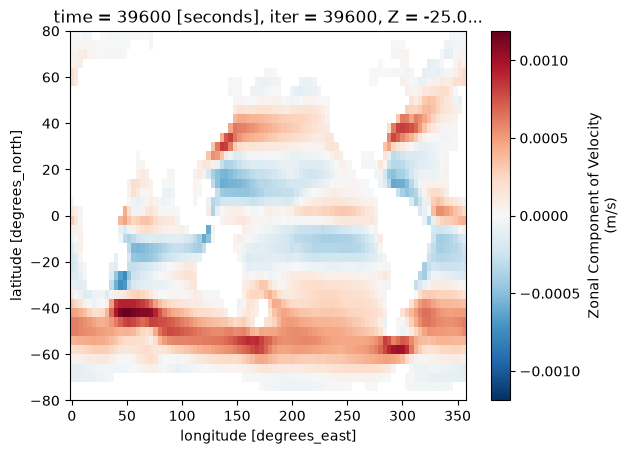

In [17]:
zonal_shear = grid.derivative(uvel_l, "Z")
zonal_shear.isel(Z=0).plot();

and the underlying xgcm operations are: 

```
grid.diff( uvel_l, 'Z' ) / ds.drW
```

Which is shown to be equivalent below:

In [18]:
expected_result = (grid.diff(uvel_l, "Z")) / ds.drW
xr.testing.assert_equal(
    zonal_shear.reset_coords(drop=True), expected_result.reset_coords(drop=True)
)

**A note on dimensions**: here we first interpolated from "Z"->"Zl" and 
the derivative operation shifted the result back from "Zl"->"Z".

In [19]:
print("1. ", ds.UVEL.dims)
print("2. ", uvel_l.dims)
print("3. ", zonal_shear.dims)

1.  ('time', 'Z', 'YC', 'XG')
2.  ('time', 'Zl', 'YC', 'XG')
3.  ('time', 'Z', 'YC', 'XG')


For reference, the vertical profiles of horizontal average of zonal velocity 
and zonal velocity shear are shown below.

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/var/folders/93/9r5v6tkd0jx8b4tmf2sgrznw0000gn/T/ipykernel_79952/3153775161.py:4: SyntaxWarning: invalid escape sequence '\p'
  "Horizontal average of zonal velocity shear, $\partial u/\partial z$",


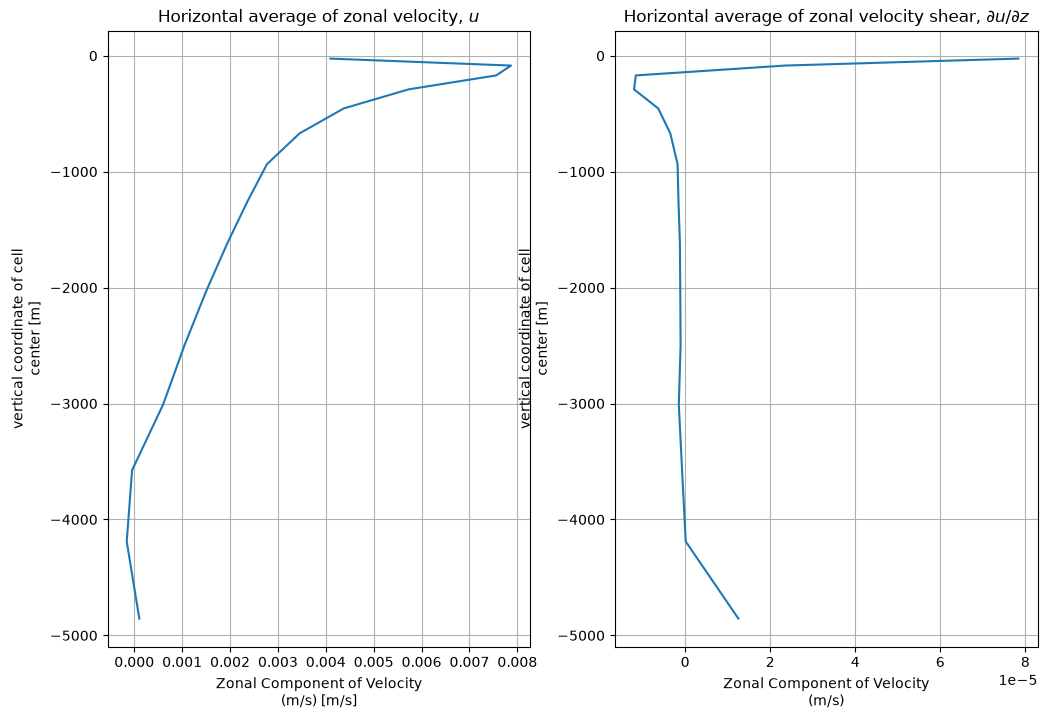

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 8))
titles = [
    "Horizontal average of zonal velocity, $u$",
    "Horizontal average of zonal velocity shear, $\partial u/\partial z$",
]
for ax, fld, title in zip(axs, [ds.UVEL, zonal_shear], titles):
    # Only select non-land (a.k.a. wet) points
    fld = fld.where(ds.maskW).isel(time=0).copy()
    grid.average(fld, ["X", "Y"]).plot(ax=ax, y="Z")
    ax.grid()
    ax.set_title(title)

And finally, for meridional velocity and temperature in the top layer:

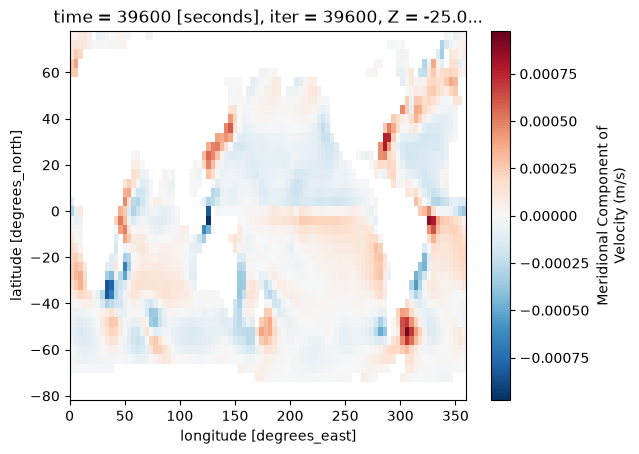

In [21]:
grid.derivative(vvel_l, "Z").isel(Z=0).plot();

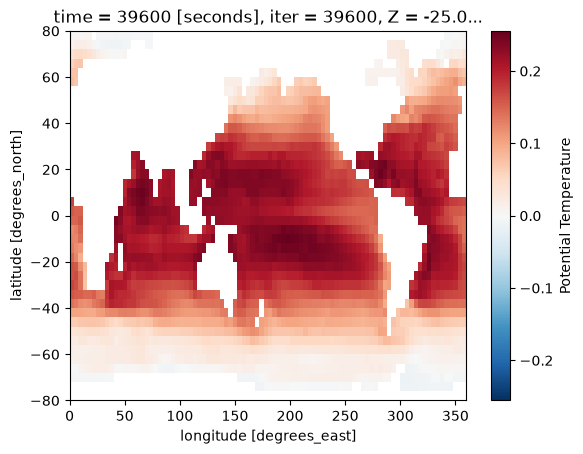

In [22]:
grid.derivative(theta_l, "Z").isel(Z=0).plot();

<div class="alert alert-info">

**Note:** The `.derivative` function performs a centered finite difference operation. 
Keep in mind that this is different from 
[finite volume differencing schemes](https://mitgcm.readthedocs.io/en/latest/algorithm/finitevol-meth.html) 
as used in many ocean models.
See [this section](https://xgcm.readthedocs.io/en/latest/xgcm-examples/02_mitgcm/#divergence) 
of documentation for some examples of how xgcm can be helpful in performing these operations.

</div>

## Metric weighted interpolation

Finally, grid metrics allow us to implement area-weighted interpolation schemes quite easily. First, however, we need to once again define new metrics in the horizontal:

In [23]:
ds["dxF"] = grid.interp(ds.dxC, "X")
ds["dyF"] = grid.interp(ds.dyC, "Y")

In [24]:
metrics = {
    ("X",): ["dxC", "dxG", "dxF"],  # X distances
    ("Y",): ["dyC", "dyG", "dyF"],  # Y distances
    ("Z",): ["drW", "drS", "drC"],  # Z distances
    ("X", "Y"): ["rA", "rAz", "rAs", "rAw"],  # Areas
}
grid = Grid(ds, metrics=metrics)

Here we show temperature interpolated in the X direction: from the tracer location to where zonal velocity is located, i.e. from `t` to `u` [in the horizontal view of the C grid shown here](https://xgcm.readthedocs.io/en/latest/grids/).

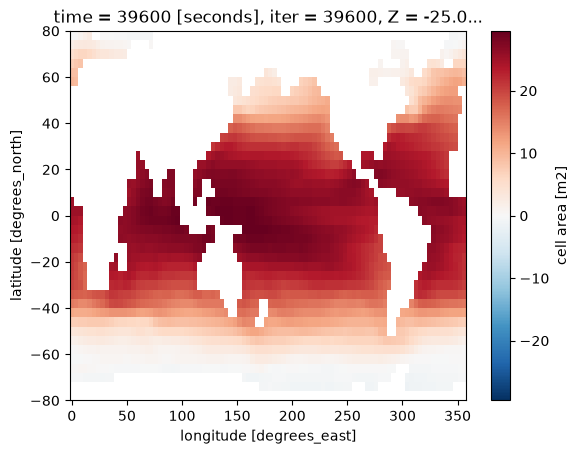

In [25]:
grid.interp(ds.THETA.where(ds.maskC), "X", metric_weighted=["X", "Y"]).isel(Z=0).plot();

This area weighted interpolation conserves tracer content in the horizontal, at least to first order 
as defined by the underlying interpolation operation. 
Note that in this example the difference between an area weighted interpolation and standard interpolation
(i.e. arithmetic mean for first order) is quite small because the underlying field is smooth.

## Updated functionality for metric handling

As of `v0.6.0 `, two new methods have been included (`set_metrics` and `interp_like`), while `get_metric` has been updated. An interactive Jupyter notebook demonstrating these features are available at this [link](https://github.com/jdldeauna/demo_notebooks_cmip6).